# FarmTech Solutions: Análise e Previsão de Rendimento Agrícola 🌾🚜

## 👨‍🎓 Integrantes (Grupo 10)
- <a href="https://www.linkedin.com/in/amanda-damasceno-martins/">566598 - Amanda Damasceno Martins</a>
- <a href="https://www.linkedin.com/in/cauasantoslt">566599 - Cauã Santos</a>
- <a href="https://www.linkedin.com/in/fabio-baldo-7959a22a/">567851 - Fabio Baldo</a>
- <a href="https://www.linkedin.com/in/giovanna-gomes-82b993372/">567169 - Giovanna Gomes Oliveira</a>
- <a href="https://www.linkedin.com/in/roberto-alvares-785059215/">568265 - Roberto Almeida Alvares</a>

## 1. Introdução
Este projeto tem como objetivo analisar uma base de dados climáticos e de solo de uma fazenda de médio porte (200 hectares). A partir da análise exploratória e do uso de algoritmos de Machine Learning, buscaremos entender as tendências de produtividade, criar agrupamentos (clusters) e prever o rendimento das safras utilizando modelos de regressão supervisionada.

In [1]:
# Importando a biblioteca de manipulação de dados
import pandas as pd

# Carregando a base de dados
# Certifique-se de que o arquivo 'crop_yield.csv' está na mesma pasta/ambiente do notebook
df = pd.read_csv("/content/crop_yield.csv")

## 2. Análise Exploratória e Limpeza de Dados (EDA)
Antes de criarmos qualquer modelo preditivo, precisamos conhecer nossos dados. Vamos verificar as primeiras linhas do dataset, identificar os tipos de variáveis e checar se existem valores nulos (ausentes) que precisem de tratamento.

In [2]:
# Exibindo as 5 primeiras linhas para entender a estrutura
display(df.head())

# Verificando os tipos de dados de cada coluna e contagem de não-nulos
print("\n--- Informações do Dataset ---")
df.info()

# Contando a quantidade exata de valores nulos por coluna
print("\n--- Valores Nulos ---")
print(df.isnull().sum())

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800



--- Informações do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB

--- Valores Nulos ---
Crop                                    0
Precipitation (mm day-1)                0
Specific Humidity at 2 Meters (g/kg)    0
Relative Humidity at 2 Meters (%)       0
Temperature at 2 Meters (C)             0
Yield                            

### 2.1 Tratamento de Dados Nulos
Como identificado na análise inicial, lidaremos com os valores ausentes (nulos) removendo as linhas defeituosas. Em um projeto onde a variável alvo (Rendimento) é crucial, a exclusão dessas poucas linhas evita que o modelo aprenda com dados sintéticos ou incorretos.

In [3]:
# Removendo qualquer linha que contenha pelo menos um valor vazio
df_limpo = df.dropna()

# Verificando o tamanho do dataset antes e depois da limpeza
print(f"Linhas antes da limpeza: {df.shape[0]}")
print(f"Linhas após a limpeza: {df_limpo.shape[0]}")

# Gerando um resumo estatístico das variáveis numéricas
display(df_limpo.describe())

Linhas antes da limpeza: 156
Linhas após a limpeza: 156


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


## 3. Visualização de Dados e Correlações 📊
Com os dados limpos, vamos utilizar as bibliotecas `matplotlib` e `seaborn` para entender visualmente o comportamento da nossa fazenda. Nosso primeiro passo é analisar a matriz de correlação para descobrir quais variáveis climáticas mais influenciam o **Rendimento** das safras.

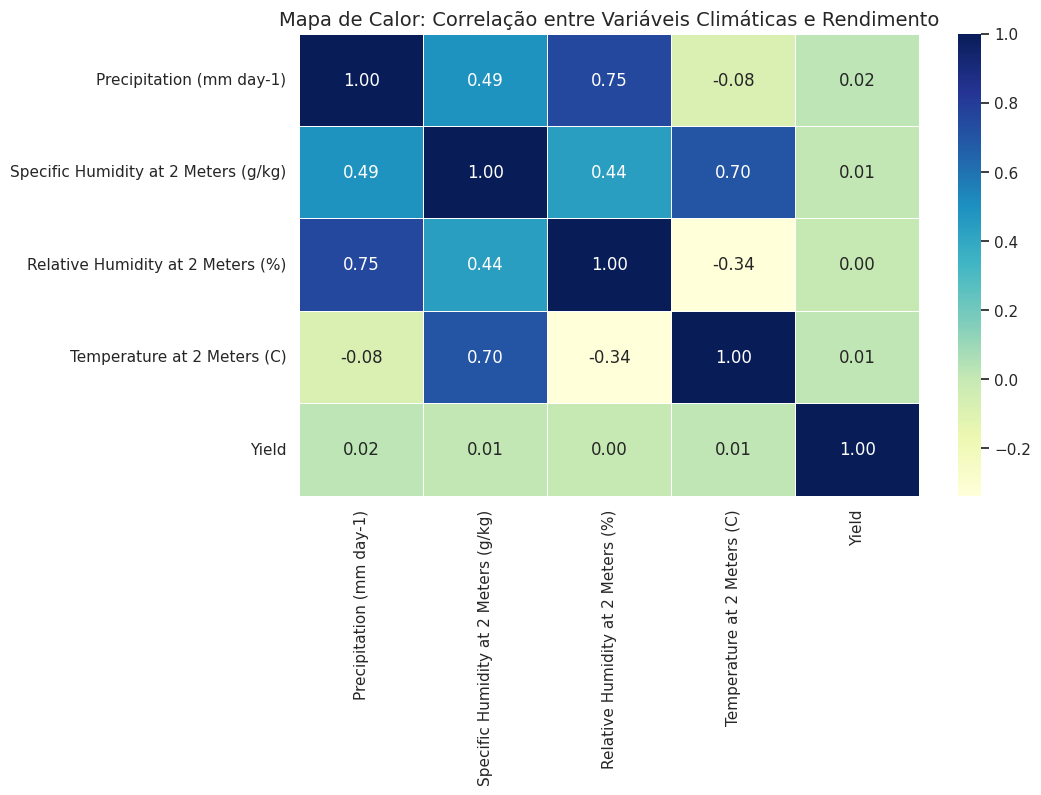

In [4]:
# Importando as bibliotecas de visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo dos gráficos para ficar mais profissional
sns.set_theme(style="whitegrid")

# Calculando a correlação apenas entre as colunas numéricas
# (Precisamos excluir a coluna 'Cultura' que é texto)
colunas_numericas = df_limpo.select_dtypes(include=['float64', 'int64'])
matriz_correlacao = colunas_numericas.corr()

# Criando o Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 6))
sns.heatmap(matriz_correlacao, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)
plt.title("Mapa de Calor: Correlação entre Variáveis Climáticas e Rendimento", fontsize=14)
plt.show()

### 3.1 Identificação de Outliers (Valores Discrepantes)
Para garantir que os nossos futuros modelos de Machine Learning não sejam influenciados negativamente por anomalias ou erros de medição, vamos utilizar *Boxplots*. Estes gráficos permitem-nos visualizar a dispersão dos dados e identificar facilmente os *outliers* nas nossas variáveis climáticas e no rendimento da safra.

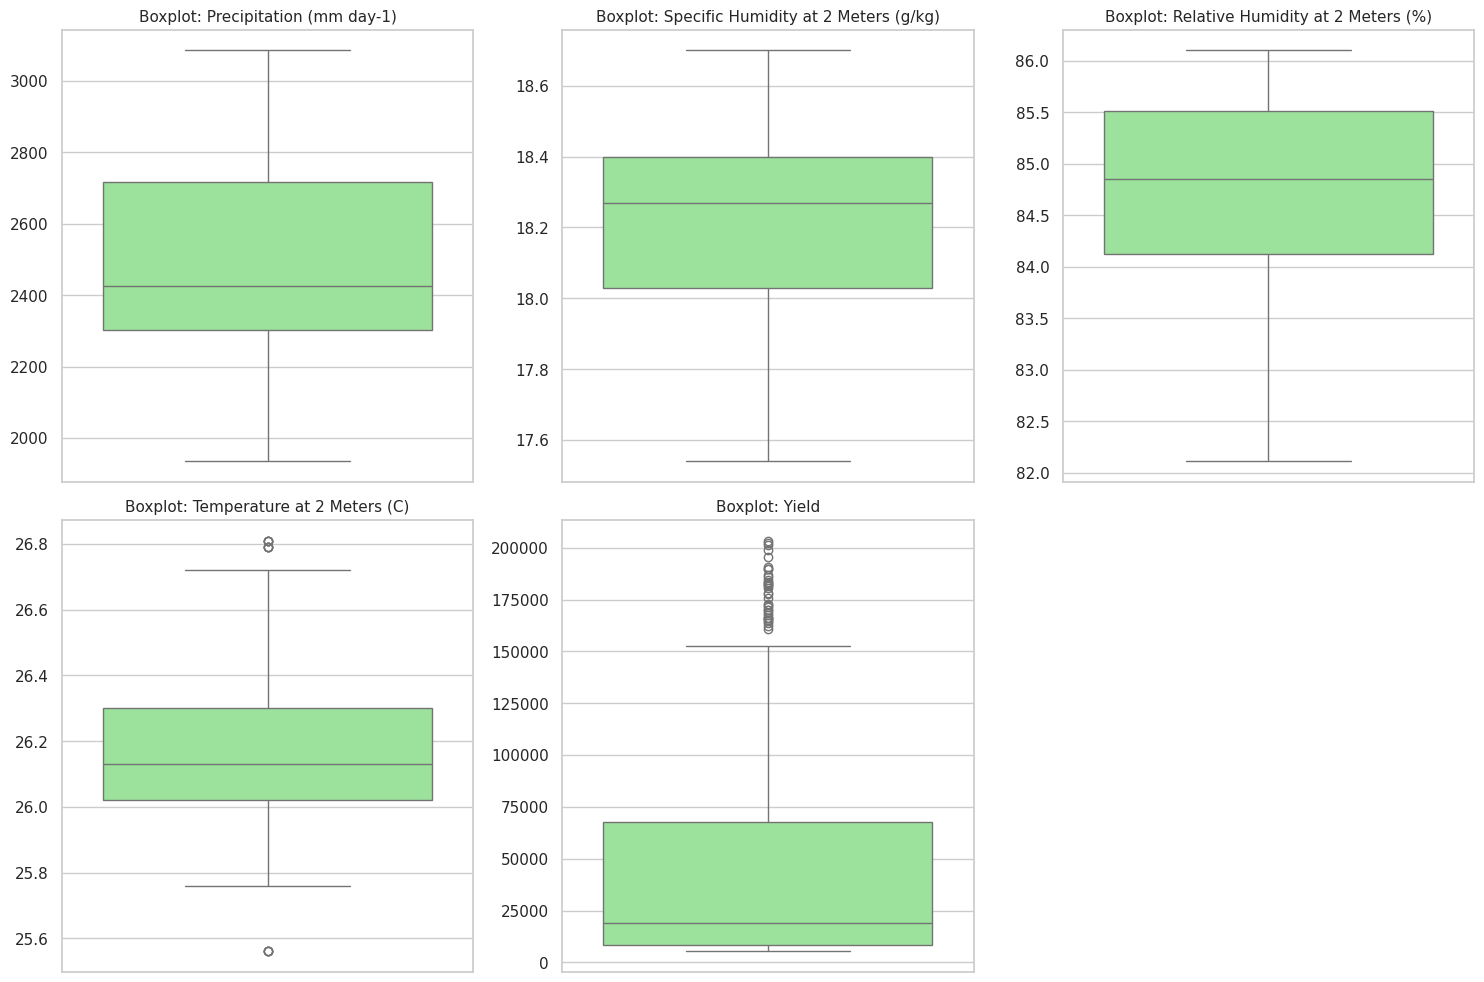

In [5]:
# Criando Boxplots para todas as variáveis numéricas
colunas_para_analisar = colunas_numericas.columns

# Definindo o tamanho da figura global
plt.figure(figsize=(15, 10))

# Laço para criar um subplot (gráfico menor) para cada coluna
for i, coluna in enumerate(colunas_para_analisar, 1):
    plt.subplot(2, 3, i) # Organiza os gráficos numa grelha de 2 linhas e 3 colunas
    sns.boxplot(y=df_limpo[coluna], color="lightgreen")
    plt.title(f"Boxplot: {coluna}", fontsize=11)
    plt.ylabel("")

# Ajusta o espaçamento para que os gráficos não fiquem sobrepostos
plt.tight_layout()
plt.show()

## 4. Clusterização das Plantações (Machine Learning Não Supervisionado) 🧩
A segunda meta da nossa entrega é encontrar tendências e agrupar as plantações com características semelhantes. Para isso, utilizaremos o algoritmo **K-Means**.

Como não sabemos previamente qual é o número ideal de grupos (clusters), vamos aplicar o **Método do Cotovelo (Elbow Method)**. Ele testa diferentes quantidades de clusters e nos mostra graficamente o ponto ideal de divisão baseado na inércia (soma dos erros quadrados).

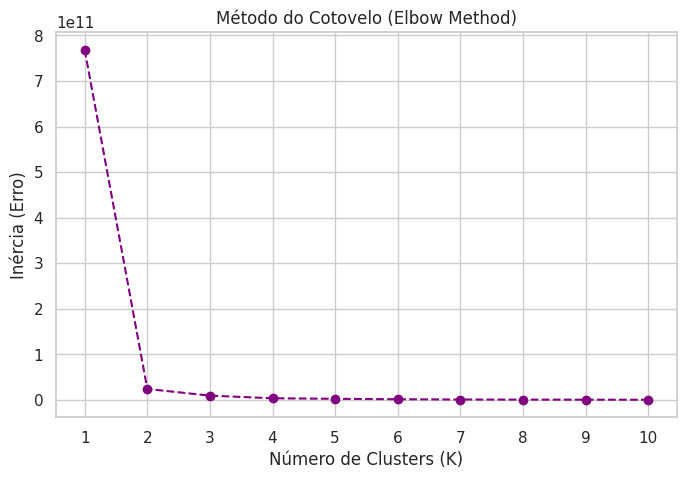

In [7]:
# Importando o algoritmo K-Means da biblioteca scikit-learn
from sklearn.cluster import KMeans

# Para a clusterização, vamos usar as variáveis que impactam a fazenda
# Selecionamos: Chuva, Temperatura, Umidade e o próprio Rendimento
dados_para_cluster = df_limpo[['Precipitation (mm day-1)', 'Temperature at 2 Meters (C)', 'Relative Humidity at 2 Meters (%)', 'Yield']]

# Lista para guardar os erros de cada tentativa
inercia = []

# Laço para testar de 1 a 10 clusters
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(dados_para_cluster)
    inercia.append(kmeans.inertia_) # Guardamos o erro dessa tentativa

# Plotando o Gráfico do Cotovelo
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inercia, marker='o', linestyle='--', color='purple')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (Erro)')
plt.xticks(range(1, 11))
plt.show()

### 4.1 Aplicando o K-Means
Com o Método do Cotovelo indicando 2 clusters como o número ideal, vamos treinar o modelo K-Means com `K=2` e adicionar uma nova coluna no nosso dataset para identificar a qual grupo cada plantação pertence. Em seguida, faremos um gráfico de dispersão (Scatter Plot) para visualizar essa separação.

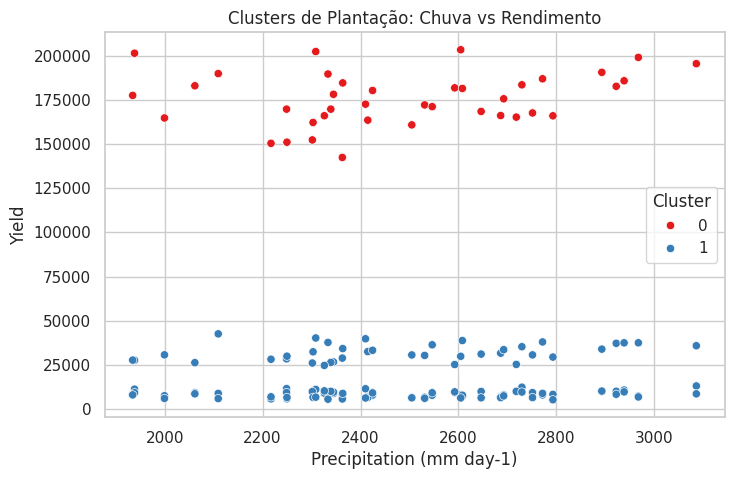

In [9]:
# Aplicando o K-Means com 2 clusters
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
df_limpo['Cluster'] = kmeans_final.fit_predict(dados_para_cluster)

# Visualizando os grupos formados (ex: Chuva vs Rendimento)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_limpo, x='Precipitation (mm day-1)', y='Yield', hue='Cluster', palette='Set1')
plt.title('Clusters de Plantação: Chuva vs Rendimento')
plt.show()

## 5. Modelagem Preditiva (Regressão Supervisionada) 🤖
Chegamos à etapa final da análise de dados. Nosso objetivo agora é prever o **Rendimento** da safra com base nas condições climáticas. Para isso, vamos separar nossos dados em variáveis preditoras (`X`) e variável alvo (`y`), e então dividir o dataset em dados de treino (80%) e dados de teste (20%).

In [11]:
from sklearn.model_selection import train_test_split

# Definindo quem é X (as características) e quem é y (o alvo a ser previsto)
# Retiramos as colunas de texto e a própria coluna alvo do X
X = df_limpo[['Precipitation (mm day-1)', 'Temperature at 2 Meters (C)', 'Relative Humidity at 2 Meters (%)']]
y = df_limpo['Yield']

# Dividindo os dados (80% para treino, 20% para teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamanho do Treino: {X_train.shape[0]} amostras")
print(f"Tamanho do Teste: {X_test.shape[0]} amostras")

Tamanho do Treino: 124 amostras
Tamanho do Teste: 32 amostras


### 5.1 Treinamento e Avaliação dos Modelos
Para não repetirmos código, criamos um dicionário contendo os 5 algoritmos de regressão escolhidos: **Árvore de Decisão, Random Forest, KNN, SVR e Gradient Boosting**.

Utilizaremos um laço de repetição (`for`) para percorrer cada modelo, treiná-lo com os dados de treino (`fit`), realizar as previsões nos dados de teste (`predict`) e calcular as nossas duas métricas de sucesso:
* **MAE (Erro Médio Absoluto):** Mostra, em média, quantas toneladas por hectare o modelo está errando. Quanto menor, melhor.
* **R² (R-Squared):** Indica a porcentagem de variação do rendimento que o modelo conseguiu aprender. Quanto mais próximo de 1 (ou 100%), melhor.

In [12]:
# Importando os 5 motores de Regressão
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Importando as métricas de avaliação
from sklearn.metrics import mean_absolute_error, r2_score

# Criando o dicionário com os modelos
# O random_state=42 garante que o resultado será o mesmo toda vez que rodarmos o código
modelos = {
    "Árvore de Decisão": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

print("--- Desempenho dos Modelos na FarmTech Solutions ---\n")

# O laço FOR que faz a mágica acontecer
for nome, modelo in modelos.items():
    # 1. Treinamento: O modelo estuda os dados
    modelo.fit(X_train, y_train)

    # 2. Previsão: O modelo tenta adivinhar o rendimento da parte separada para teste
    previsoes = modelo.predict(X_test)

    # 3. Avaliação: Comparamos as previsões com a realidade (y_test)
    mae = mean_absolute_error(y_test, previsoes)
    r2 = r2_score(y_test, previsoes)

    # Imprimindo os resultados de forma amigável
    print(f"Modelo: {nome}")
    print(f"MAE (Erro): {mae:.2f} toneladas/hectare")
    print(f"R² (Precisão): {r2:.2f}")
    print("-" * 40)

--- Desempenho dos Modelos na FarmTech Solutions ---

Modelo: Árvore de Decisão
MAE (Erro): 75914.27 toneladas/hectare
R² (Precisão): -1.20
----------------------------------------
Modelo: Random Forest
MAE (Erro): 72417.84 toneladas/hectare
R² (Precisão): -0.91
----------------------------------------
Modelo: KNN
MAE (Erro): 68257.11 toneladas/hectare
R² (Precisão): -0.75
----------------------------------------
Modelo: SVR
MAE (Erro): 38974.59 toneladas/hectare
R² (Precisão): -0.31
----------------------------------------
Modelo: Gradient Boosting
MAE (Erro): 75183.94 toneladas/hectare
R² (Precisão): -1.14
----------------------------------------


### 5.2 Otimização dos Modelos: Padronização de Escala
Na nossa primeira rodada, observamos que os modelos tiveram um desempenho muito prejudicado (R² negativo). Isso ocorre frequentemente porque as nossas variáveis possuem escalas drasticamente diferentes (ex: temperatura na casa dos 20ºC e rendimento na casa das dezenas de milhares), confundindo algoritmos baseados em cálculo de distância matemática.

Para corrigir essa distorção e tentar melhorar a precisão da IA, vamos aplicar a técnica de Padronização (`StandardScaler`), que coloca todas as variáveis preditoras na mesma proporção estatística sem alterar seus padrões originais.

In [14]:
from sklearn.preprocessing import StandardScaler

# 1. Criando o nosso padronizador de escala
scaler = StandardScaler()

# 2. Ajustando (fit) e transformando os dados de TREINO
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transformando os dados de TESTE
# (Regra de ouro: nunca fazemos 'fit' no teste, apenas 'transform' para evitar vazamento de dados)
X_test_scaled = scaler.transform(X_test)

print("--- Desempenho dos Modelos com Dados Padronizados ---\n")

# Rodando o mesmo laço FOR, mas agora entregando os dados escalados (X_train_scaled)
for nome, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    previsoes = modelo.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, previsoes)
    r2 = r2_score(y_test, previsoes)

    print(f"Modelo: {nome}")
    print(f"MAE (Erro): {mae:.2f} toneladas/hectare")
    print(f"R² (Precisão): {r2:.2f}")
    print("-" * 40)

--- Desempenho dos Modelos com Dados Padronizados ---

Modelo: Árvore de Decisão
MAE (Erro): 75914.27 toneladas/hectare
R² (Precisão): -1.20
----------------------------------------
Modelo: Random Forest
MAE (Erro): 72417.84 toneladas/hectare
R² (Precisão): -0.91
----------------------------------------
Modelo: KNN
MAE (Erro): 65127.07 toneladas/hectare
R² (Precisão): -0.55
----------------------------------------
Modelo: SVR
MAE (Erro): 38974.96 toneladas/hectare
R² (Precisão): -0.31
----------------------------------------
Modelo: Gradient Boosting
MAE (Erro): 75183.94 toneladas/hectare
R² (Precisão): -1.14
----------------------------------------


## 6. Conclusões e Limitações do Trabalho 📝

Após a execução e otimização dos cinco modelos de regressão, observamos que todos apresentaram um R² (R-Squared) negativo, sendo o **SVR (Support Vector Regressor)** o modelo com o menor Erro Médio Absoluto (MAE), errando cerca de 38.974 toneladas/hectare.

**Limitações Encontradas:**
O desempenho insatisfatório dos modelos comprova uma premissa fundamental de Data Science: a qualidade da predição é limitada pelas variáveis disponíveis ("Garbage In, Garbage Out"). As variáveis climáticas fornecidas no dataset (precipitação, temperatura e umidade relativa do ar) não possuem correlação forte o suficiente para explicar as variações drásticas no rendimento da safra por conta própria.

**Pontos Fortes e Próximos Passos:**
O ponto forte desta análise foi a identificação clara de que o clima, isoladamente, não define a produtividade da FarmTech Solutions. Para que a previsão de rendimento seja viável no futuro, é estritamente necessário enriquecer esta base de dados com informações do solo. A integração de sensores IoT (como os desenvolvidos no desafio "Ir Além") para monitorar níveis de NPK, pH e umidade do solo em tempo real fornecerá o sinal matemático que falta para que algoritmos como o Random Forest e o SVR atinjam uma alta precisão preditiva.